In [1]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# import des fonctionalités des packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np 
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")


In [659]:
# définir le chemin dans lequel se situe le fichier à importer:
chemin_data = 'P:/e_23_sae503_eq5/CU 2/Fréquentation journalière 2022-2023.xlsx'

# importer le fichier dans un objet python dataframe, nommé "data" pour l'exemple
data = pd.read_excel(chemin_data)

# avoir une idée de la dimension des données
nombre_lignes, nombre_colonnes = data.shape
print("Nombre de lignes:", nombre_lignes)
print("Nombre de colonnes:", nombre_colonnes)

# visualiser les 5 premières lignes du dataframe
data.head(5)
data['Gare']=data['Nom de la gare']
data.drop('Nom de la gare', axis=1, inplace=True)


Nombre de lignes: 4380
Nombre de colonnes: 5


In [660]:
data.head(5)

,UIC,DRG,Date,Fréquentation gare,Gare
0,87484006,DRG B-CVL-PDL,2023-12-31,16754,Angers Saint-Laud
1,87473207,DRG B-CVL-PDL,2023-12-31,2274,Guingamp
2,87481002,DRG B-CVL-PDL,2023-12-31,34282,Nantes
3,87471003,DRG B-CVL-PDL,2023-12-31,37472,Rennes
4,87473009,DRG B-CVL-PDL,2023-12-31,2167,Saint-Brieuc


In [661]:
# connaître le format de la colonne "Date"
types_de_donnees = data['Date '].apply(type)

# afficher le résultat: ici toutes les données de la colonne sont considérées comme des chaînes de caractères (str)
print(f"Le type de données de la colonne 'Date' est : {types_de_donnees}")

Le type de données de la colonne 'Date' est : 0       <class 'pandas._libs.tslibs.timestamps.Timesta...
1       <class 'pandas._libs.tslibs.timestamps.Timesta...
2       <class 'pandas._libs.tslibs.timestamps.Timesta...
3       <class 'pandas._libs.tslibs.timestamps.Timesta...
4       <class 'pandas._libs.tslibs.timestamps.Timesta...
                              ...                        
4375    <class 'pandas._libs.tslibs.timestamps.Timesta...
4376    <class 'pandas._libs.tslibs.timestamps.Timesta...
4377    <class 'pandas._libs.tslibs.timestamps.Timesta...
4378    <class 'pandas._libs.tslibs.timestamps.Timesta...
4379    <class 'pandas._libs.tslibs.timestamps.Timesta...
Name: Date , Length: 4380, dtype: object


In [662]:
# convertir une chaîne de caractères en format date
data['Date '] = pd.to_datetime(data['Date '], errors='coerce')

# vérifier le changement de format: toutes les données de la colonne sont maintenant en format timestamps
types_de_donnees = data['Date '].apply(type)
print(f"Le type de données de la colonne 'Date' est : {types_de_donnees}")


Le type de données de la colonne 'Date' est : 0       <class 'pandas._libs.tslibs.timestamps.Timesta...
1       <class 'pandas._libs.tslibs.timestamps.Timesta...
2       <class 'pandas._libs.tslibs.timestamps.Timesta...
3       <class 'pandas._libs.tslibs.timestamps.Timesta...
4       <class 'pandas._libs.tslibs.timestamps.Timesta...
                              ...                        
4375    <class 'pandas._libs.tslibs.timestamps.Timesta...
4376    <class 'pandas._libs.tslibs.timestamps.Timesta...
4377    <class 'pandas._libs.tslibs.timestamps.Timesta...
4378    <class 'pandas._libs.tslibs.timestamps.Timesta...
4379    <class 'pandas._libs.tslibs.timestamps.Timesta...
Name: Date , Length: 4380, dtype: object


In [663]:
# Extraire l'année de la date et la stocker dans une nouvelle colonne "annee"
data['annee'] = data['Date '].apply(lambda x: x.year if pd.notnull(x) else None)

# Extraire le mois de la date et la stocker dans une nouvelle colonne "mois"
data['mois'] = data['Date '].apply(lambda x: x.month if pd.notnull(x) else None)

# Extraire le jour de la date et la stocker dans une nouvelle colonne "mois"
data['jour'] = data['Date '].apply(lambda x: x.day if pd.notnull(x) else None)

from datetime import datetime

# Obtenez la date actuelle

# Obtenez le numéro de la semaine avec le format %U
data['numero_semaine'] = data['Date '].apply(lambda x: x.strftime("%U") if pd.notnull(x) else None)
data

,UIC,DRG,Date,Fréquentation gare,Gare,annee,mois,jour,numero_semaine
0,87484006,DRG B-CVL-PDL,2023-12-31,16754,Angers Saint-Laud,2023,12,31,53
1,87473207,DRG B-CVL-PDL,2023-12-31,2274,Guingamp,2023,12,31,53
2,87481002,DRG B-CVL-PDL,2023-12-31,34282,Nantes,2023,12,31,53
3,87471003,DRG B-CVL-PDL,2023-12-31,37472,Rennes,2023,12,31,53
4,87473009,DRG B-CVL-PDL,2023-12-31,2167,Saint-Brieuc,2023,12,31,53
...,...,...,...,...,...,...,...,...,...
4375,87473207,DRG B-CVL-PDL,2022-01-01,2319,Guingamp,2022,1,1,00
4376,87481002,DRG B-CVL-PDL,2022-01-01,29220,Nantes,2022,1,1,00
4377,87471003,DRG B-CVL-PDL,2022-01-01,34800,Rennes,2022,1,1,00
4378,87473009,DRG B-CVL-PDL,2022-01-01,2474,Saint-Brieuc,2022,1,1,00


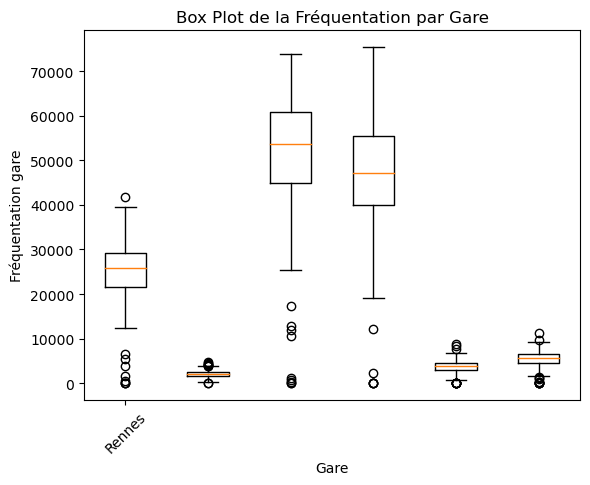

In [664]:
plt.boxplot([group['Fréquentation gare'] for name, group in data.groupby('Gare')])
plt.xlabel('Gare')
plt.ylabel('Fréquentation gare')
plt.title('Box Plot de la Fréquentation par Gare')
plt.xticks(range(1, len(datalim['Gare'].unique()) + 1), datalim['Gare'].unique(), rotation=45)
plt.show()

In [665]:
data["weekday"] = data["Date "].dt.dayofweek+1
data.head(10)

,UIC,DRG,Date,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday
0,87484006,DRG B-CVL-PDL,2023-12-31,16754,Angers Saint-Laud,2023,12,31,53,7
1,87473207,DRG B-CVL-PDL,2023-12-31,2274,Guingamp,2023,12,31,53,7
2,87481002,DRG B-CVL-PDL,2023-12-31,34282,Nantes,2023,12,31,53,7
3,87471003,DRG B-CVL-PDL,2023-12-31,37472,Rennes,2023,12,31,53,7
4,87473009,DRG B-CVL-PDL,2023-12-31,2167,Saint-Brieuc,2023,12,31,53,7
5,87476606,DRG B-CVL-PDL,2023-12-31,3457,Vannes,2023,12,31,53,7
6,87484006,DRG B-CVL-PDL,2023-12-30,19781,Angers Saint-Laud,2023,12,30,52,6
7,87473207,DRG B-CVL-PDL,2023-12-30,1680,Guingamp,2023,12,30,52,6
8,87481002,DRG B-CVL-PDL,2023-12-30,46633,Nantes,2023,12,30,52,6
9,87471003,DRG B-CVL-PDL,2023-12-30,48441,Rennes,2023,12,30,52,6


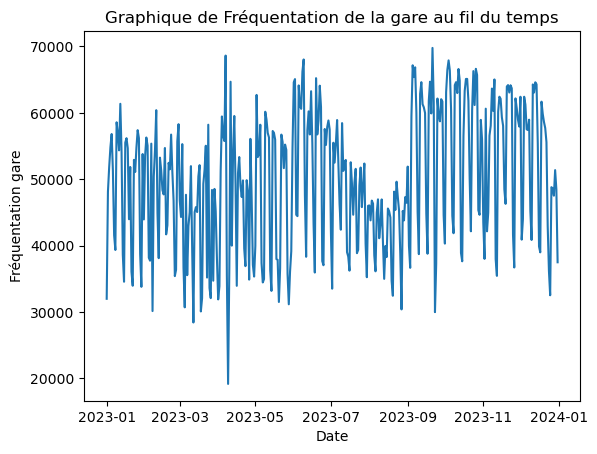

In [666]:
plt.plot(datalim['Date '], datalim['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()

## Définition du seuil 

In [667]:
data

,UIC,DRG,Date,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday
0,87484006,DRG B-CVL-PDL,2023-12-31,16754,Angers Saint-Laud,2023,12,31,53,7
1,87473207,DRG B-CVL-PDL,2023-12-31,2274,Guingamp,2023,12,31,53,7
2,87481002,DRG B-CVL-PDL,2023-12-31,34282,Nantes,2023,12,31,53,7
3,87471003,DRG B-CVL-PDL,2023-12-31,37472,Rennes,2023,12,31,53,7
4,87473009,DRG B-CVL-PDL,2023-12-31,2167,Saint-Brieuc,2023,12,31,53,7
...,...,...,...,...,...,...,...,...,...,...
4375,87473207,DRG B-CVL-PDL,2022-01-01,2319,Guingamp,2022,1,1,00,6
4376,87481002,DRG B-CVL-PDL,2022-01-01,29220,Nantes,2022,1,1,00,6
4377,87471003,DRG B-CVL-PDL,2022-01-01,34800,Rennes,2022,1,1,00,6
4378,87473009,DRG B-CVL-PDL,2022-01-01,2474,Saint-Brieuc,2022,1,1,00,6


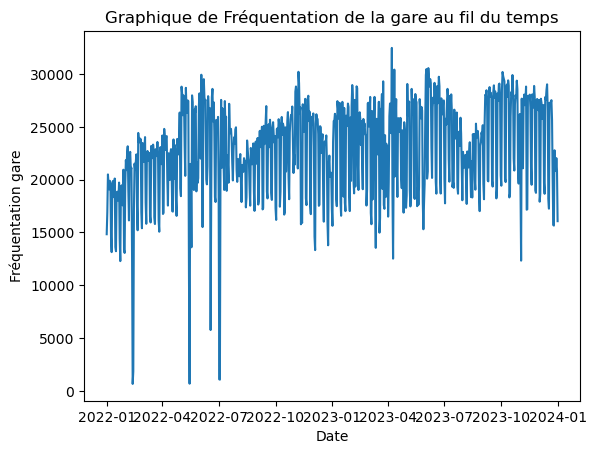

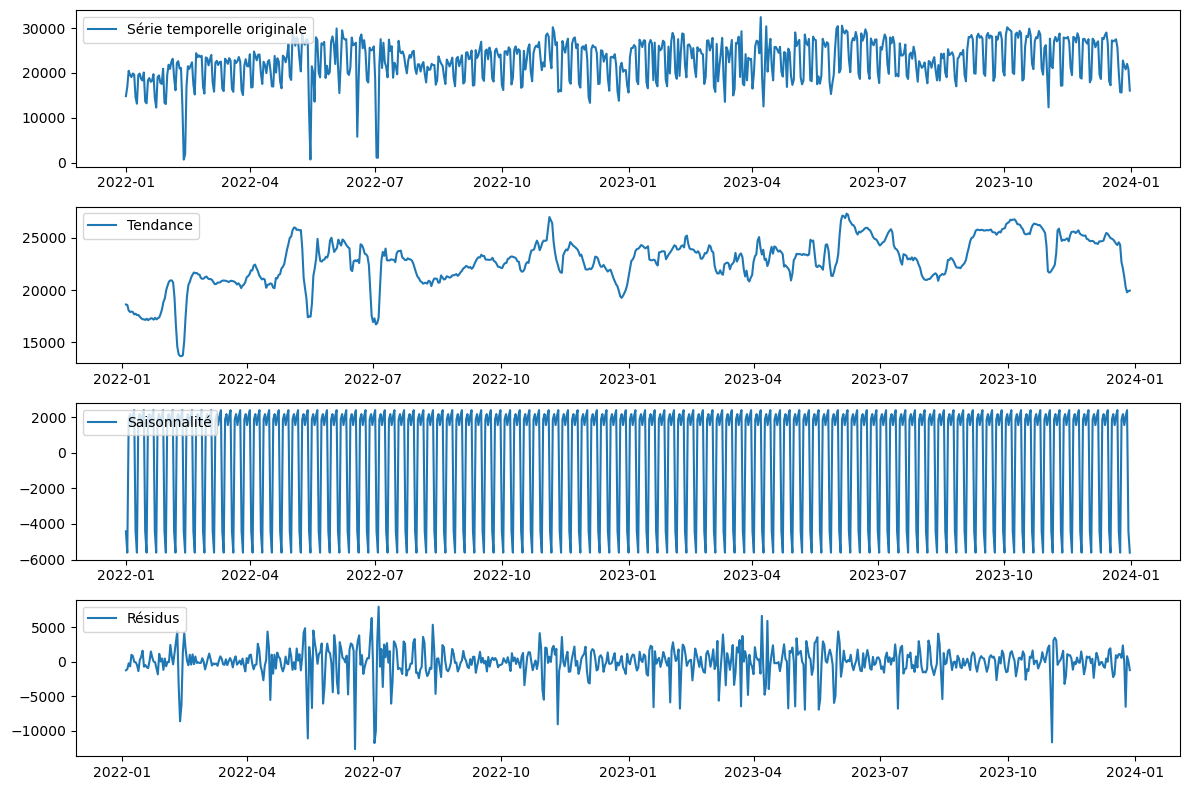

Déciles des résidus:
Décile 10% : -1769.8340924159052
Décile 11% : -1047.0082633501481
Décile 12% : -548.0126345048869
Décile 13% : -181.33795279500592
Décile 14% : 117.5067998633358
Décile 15% : 512.7564713488123
Décile 16% : 820.305360000609
Décile 17% : 1366.8149829423965
Décile 18% : 2182.468570152114


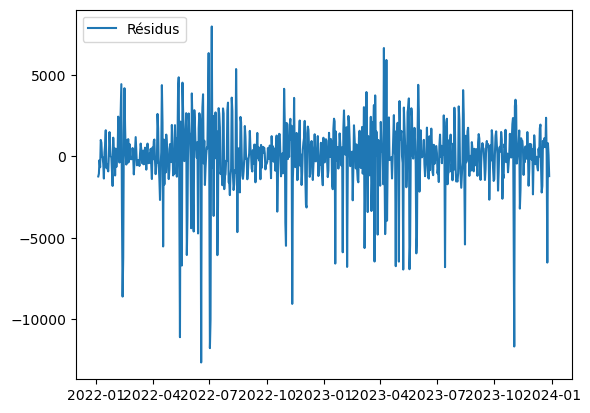

In [668]:
data_glob=data.groupby('Date ').mean()
data_glob

#data=datalim.head(365)
#data.set_index('Date ', inplace=True)

# Tracer la série temporelle 'Fréquentation gare'
plt.plot(data_glob.index, data_glob['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()


# Appliquer la décomposition saisonnière
result = seasonal_decompose(data_glob['Fréquentation gare'], model='additive')

# Extraire les composants de tendance, saisonnalité et résidus
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Afficher les composants décomposés
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data_glob['Fréquentation gare'], label='Série temporelle originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

# Calculer les déciles des résidus
deciles = np.percentile(residual.dropna(), np.arange(10, 100, 10))

# Afficher les déciles
print("Déciles des résidus:")
for i, decile_value in enumerate(deciles, 10):
    print(f"Décile {i}% : {decile_value}")

data_glob['Affluence_inhabituelle']=np.where(residual > deciles[-1], 1, 0)

data_glob
seuil = deciles[-1]


## Rennes

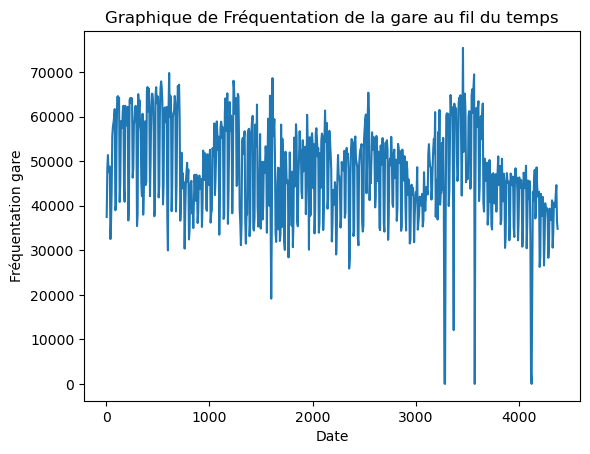

In [669]:
data_rennes=data.query('Gare == "Rennes"')
#data=datalim.head(365)
#data.set_index('Date ', inplace=True)

# Tracer la série temporelle 'Fréquentation gare'
plt.plot(data_rennes.index, data_rennes['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()

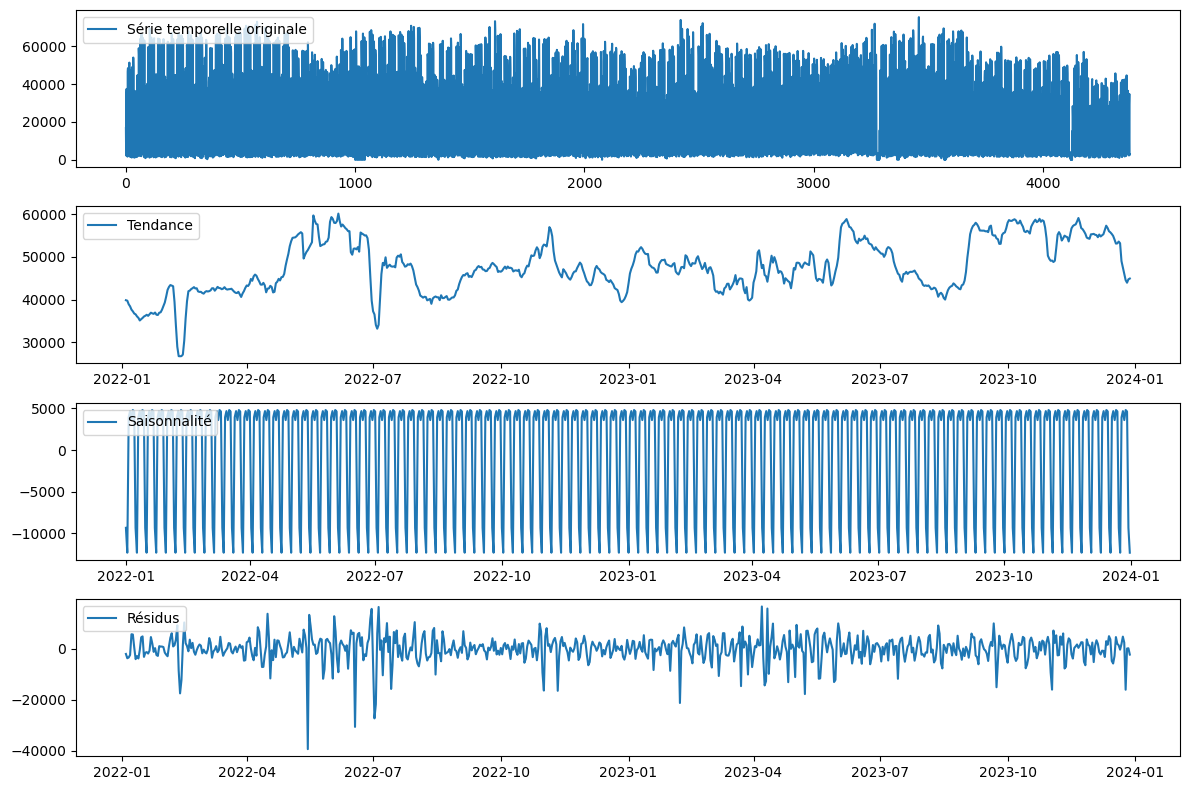

In [670]:
data_rennes.set_index('Date ', inplace=True)
# Appliquer la décomposition saisonnière
result = seasonal_decompose(data_rennes['Fréquentation gare'], model='additive')

# Extraire les composants de tendance, saisonnalité et résidus
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Afficher les composants décomposés
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data['Fréquentation gare'], label='Série temporelle originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

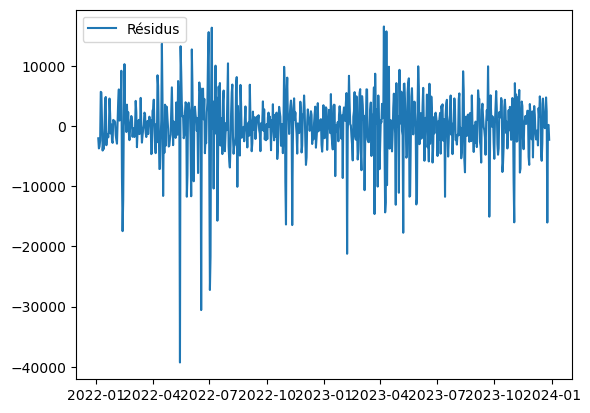

In [671]:
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

In [672]:
# Calculer les déciles des résidus
deciles = np.percentile(residual.dropna(), np.arange(10, 100, 10))

# Afficher les déciles
print("Déciles des résidus:")
for i, decile_value in enumerate(deciles, 10):
    print(f"Décile {i}% : {decile_value}")

Déciles des résidus:
Décile 10% : -4941.942522214264
Décile 11% : -2870.377454999917
Décile 12% : -1705.9488782368803
Décile 13% : -599.134061742696
Décile 14% : 388.38646530307597
Décile 15% : 1379.7469368703478
Décile 16% : 2188.3949351099686
Décile 17% : 3418.8334993370054
Décile 18% : 5285.4581792687295


In [673]:
data_rennes['Affluence_inhabituelle']=np.where(residual > seuil, 1, 0)

In [674]:
dates_dernier_decile

DatetimeIndex(['2022-01-18', '2022-02-26', '2022-02-27', '2022-02-28',
               '2022-03-03', '2022-03-04', '2022-04-06', '2022-05-21',
               '2022-05-22', '2022-05-28', '2022-05-29', '2022-06-05',
               '2022-06-17', '2022-08-01', '2022-08-02', '2022-08-13',
               '2022-08-17', '2022-08-19', '2022-09-01', '2022-09-04',
               '2022-09-10', '2022-09-22', '2022-09-26', '2022-09-30',
               '2022-10-10', '2022-10-12', '2022-10-13', '2022-10-14',
               '2022-10-24', '2022-10-25', '2022-10-28', '2022-11-13',
               '2022-11-22', '2022-11-29', '2022-11-30', '2022-12-15',
               '2023-02-08', '2023-02-13', '2023-02-17', '2023-02-23',
               '2023-02-24', '2023-03-05', '2023-05-07', '2023-05-13',
               '2023-05-21', '2023-05-27', '2023-05-28', '2023-06-03',
               '2023-06-04', '2023-06-11', '2023-06-17', '2023-06-18',
               '2023-06-29', '2023-06-30', '2023-07-04', '2023-07-05',
      

In [675]:
data_rennes

,UIC,DRG,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday,Affluence_inhabituelle
Date,,,,,,,,,,
2023-12-31,87471003,DRG B-CVL-PDL,37472,Rennes,2023,12,31,53,7,0
2023-12-30,87471003,DRG B-CVL-PDL,48441,Rennes,2023,12,30,52,6,0
2023-12-29,87471003,DRG B-CVL-PDL,51361,Rennes,2023,12,29,52,5,0
2023-12-28,87471003,DRG B-CVL-PDL,47510,Rennes,2023,12,28,52,4,0
2023-12-27,87471003,DRG B-CVL-PDL,48599,Rennes,2023,12,27,52,3,0
...,...,...,...,...,...,...,...,...,...,...
2022-01-05,87471003,DRG B-CVL-PDL,39693,Rennes,2022,1,5,01,3,0
2022-01-04,87471003,DRG B-CVL-PDL,42564,Rennes,2022,1,4,01,2,0
2022-01-03,87471003,DRG B-CVL-PDL,44614,Rennes,2022,1,3,01,1,0


In [676]:
data

,UIC,DRG,Date,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday
0,87484006,DRG B-CVL-PDL,2023-12-31,16754,Angers Saint-Laud,2023,12,31,53,7
1,87473207,DRG B-CVL-PDL,2023-12-31,2274,Guingamp,2023,12,31,53,7
2,87481002,DRG B-CVL-PDL,2023-12-31,34282,Nantes,2023,12,31,53,7
3,87471003,DRG B-CVL-PDL,2023-12-31,37472,Rennes,2023,12,31,53,7
4,87473009,DRG B-CVL-PDL,2023-12-31,2167,Saint-Brieuc,2023,12,31,53,7
...,...,...,...,...,...,...,...,...,...,...
4375,87473207,DRG B-CVL-PDL,2022-01-01,2319,Guingamp,2022,1,1,00,6
4376,87481002,DRG B-CVL-PDL,2022-01-01,29220,Nantes,2022,1,1,00,6
4377,87471003,DRG B-CVL-PDL,2022-01-01,34800,Rennes,2022,1,1,00,6
4378,87473009,DRG B-CVL-PDL,2022-01-01,2474,Saint-Brieuc,2022,1,1,00,6


## Nantes 

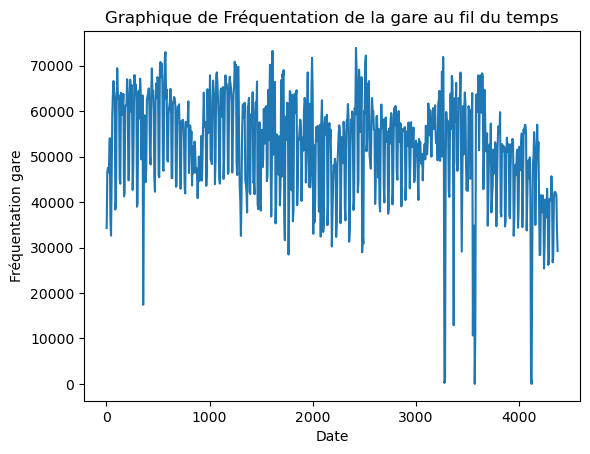

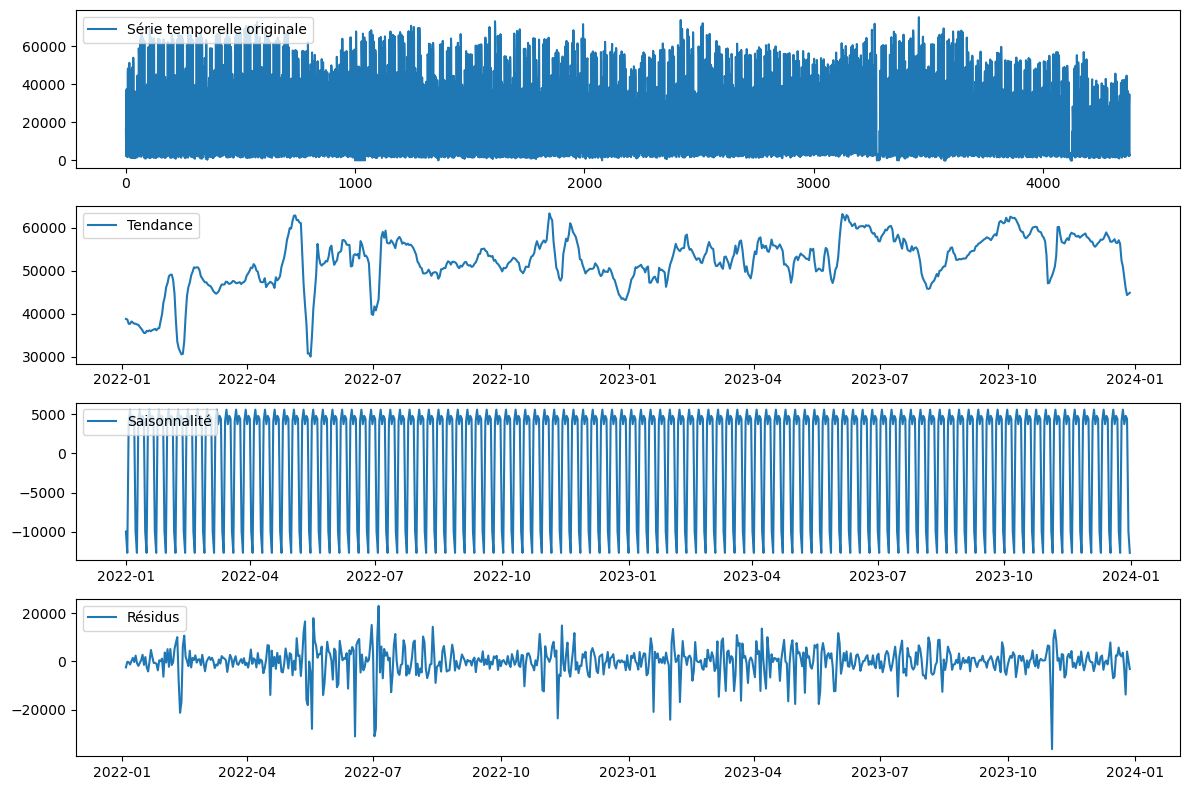

Déciles des résidus:
Décile 10% : -5535.081994444521
Décile 11% : -2948.5731192178146
Décile 12% : -1523.205094039103
Décile 13% : -502.2518986907655
Décile 14% : 354.3933162884314
Décile 15% : 1345.2194285257065
Décile 16% : 2256.8117002103336
Décile 17% : 3480.5772275228223
Décile 18% : 6272.037524386159


,UIC,DRG,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday,Affluence_inhabituelle
Date,,,,,,,,,,
2023-12-31,87481002,DRG B-CVL-PDL,34282,Nantes,2023,12,31,53,7,0
2023-12-30,87481002,DRG B-CVL-PDL,46633,Nantes,2023,12,30,52,6,0
2023-12-29,87481002,DRG B-CVL-PDL,47517,Nantes,2023,12,29,52,5,0
2023-12-28,87481002,DRG B-CVL-PDL,46520,Nantes,2023,12,28,52,4,0
2023-12-27,87481002,DRG B-CVL-PDL,48908,Nantes,2023,12,27,52,3,0
...,...,...,...,...,...,...,...,...,...,...
2022-01-05,87481002,DRG B-CVL-PDL,42259,Nantes,2022,1,5,01,3,0
2022-01-04,87481002,DRG B-CVL-PDL,41914,Nantes,2022,1,4,01,2,0
2022-01-03,87481002,DRG B-CVL-PDL,41552,Nantes,2022,1,3,01,1,0


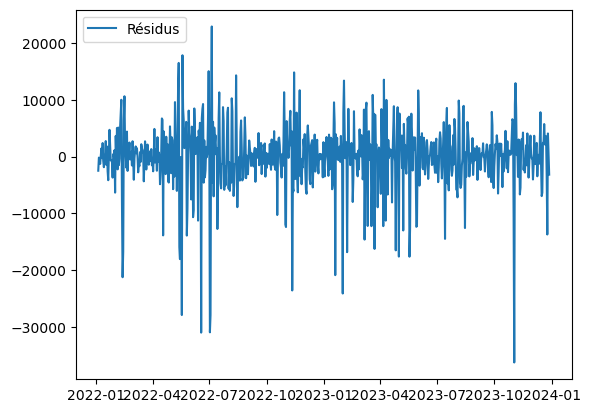

In [677]:
data_Nantes=data.query('Gare == "Nantes"')
#data=datalim.head(365)
#data.set_index('Date ', inplace=True)

# Tracer la série temporelle 'Fréquentation gare'
plt.plot(data_Nantes.index, data_Nantes['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()

data_Nantes.set_index('Date ', inplace=True)
# Appliquer la décomposition saisonnière
result = seasonal_decompose(data_Nantes['Fréquentation gare'], model='additive')

# Extraire les composants de tendance, saisonnalité et résidus
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Afficher les composants décomposés
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data['Fréquentation gare'], label='Série temporelle originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

# Calculer les déciles des résidus
deciles = np.percentile(residual.dropna(), np.arange(10, 100, 10))

# Afficher les déciles
print("Déciles des résidus:")
for i, decile_value in enumerate(deciles, 10):
    print(f"Décile {i}% : {decile_value}")

data_Nantes['Affluence_inhabituelle']=np.where(residual > seuil, 1, 0)

data_Nantes



## Angers 

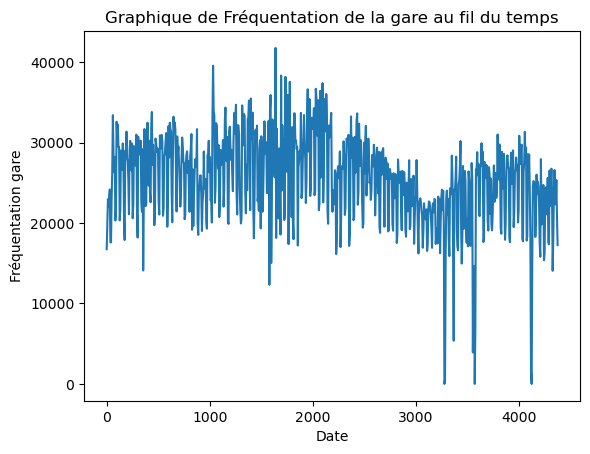

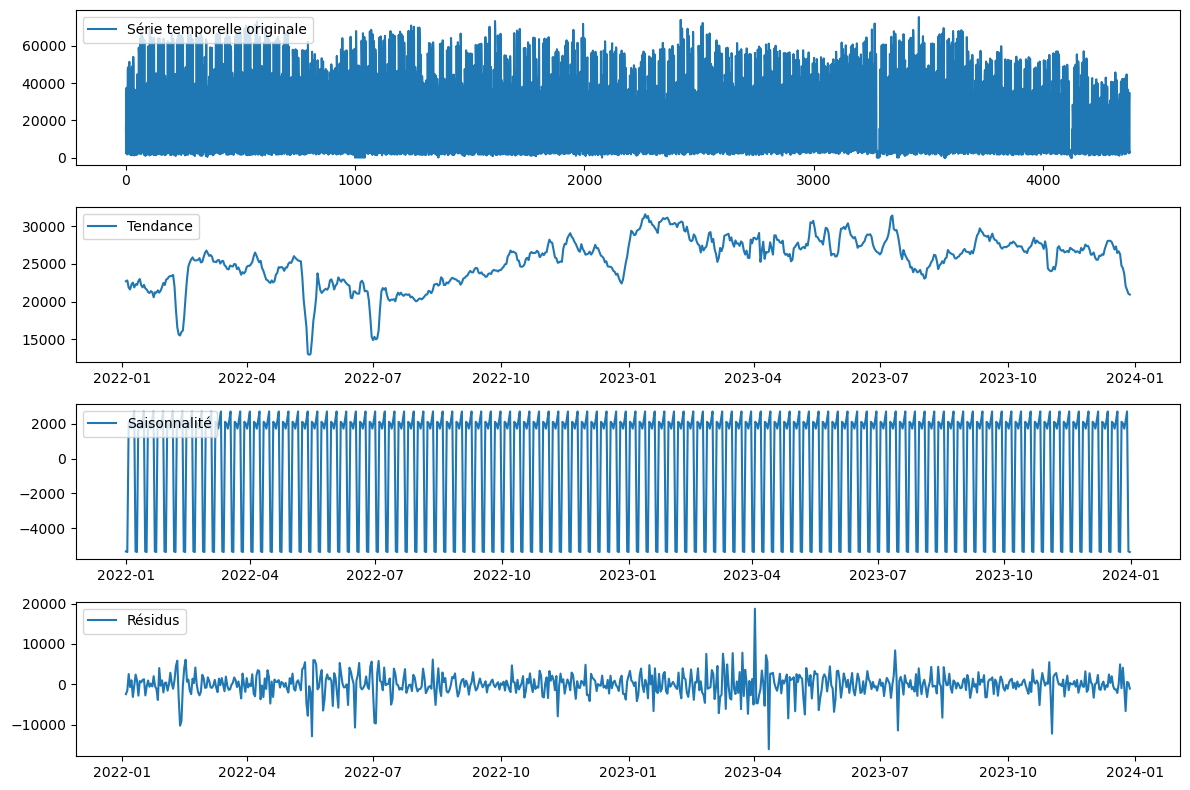

Déciles des résidus:
Décile 10% : -2983.9889324960754
Décile 11% : -1715.849796146988
Décile 12% : -965.8646606514088
Décile 13% : -413.63440086265814
Décile 14% : 67.36970934752037
Décile 15% : 579.9206375455326
Décile 16% : 1120.3462963527475
Décile 17% : 1839.991095243175
Décile 18% : 3008.3870730517788


,UIC,DRG,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday,Affluence_inhabituelle
Date,,,,,,,,,,
2023-12-31,87484006,DRG B-CVL-PDL,16754,Angers Saint-Laud,2023,12,31,53,7,0
2023-12-30,87484006,DRG B-CVL-PDL,19781,Angers Saint-Laud,2023,12,30,52,6,0
2023-12-29,87484006,DRG B-CVL-PDL,22976,Angers Saint-Laud,2023,12,29,52,5,0
2023-12-28,87484006,DRG B-CVL-PDL,22083,Angers Saint-Laud,2023,12,28,52,4,0
2023-12-27,87484006,DRG B-CVL-PDL,23190,Angers Saint-Laud,2023,12,27,52,3,0
...,...,...,...,...,...,...,...,...,...,...
2022-01-05,87484006,DRG B-CVL-PDL,22997,Angers Saint-Laud,2022,1,5,01,3,0
2022-01-04,87484006,DRG B-CVL-PDL,22320,Angers Saint-Laud,2022,1,4,01,2,0
2022-01-03,87484006,DRG B-CVL-PDL,25354,Angers Saint-Laud,2022,1,3,01,1,0


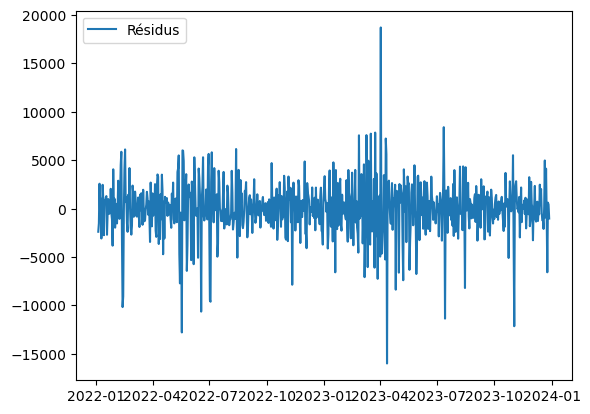

In [678]:
data_Angers=data.query('Gare == "Angers Saint-Laud"')
#data=datalim.head(365)
#data.set_index('Date ', inplace=True)

# Tracer la série temporelle 'Fréquentation gare'
plt.plot(data_Angers.index, data_Angers['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()

data_Angers.set_index('Date ', inplace=True)
# Appliquer la décomposition saisonnière
result = seasonal_decompose(data_Angers['Fréquentation gare'], model='additive')

# Extraire les composants de tendance, saisonnalité et résidus
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Afficher les composants décomposés
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data['Fréquentation gare'], label='Série temporelle originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

# Calculer les déciles des résidus
deciles = np.percentile(residual.dropna(), np.arange(10, 100, 10))

# Afficher les déciles
print("Déciles des résidus:")
for i, decile_value in enumerate(deciles, 10):
    print(f"Décile {i}% : {decile_value}")

data_Angers['Affluence_inhabituelle']=np.where(residual > seuil, 1, 0)

data_Angers



## Vannes 

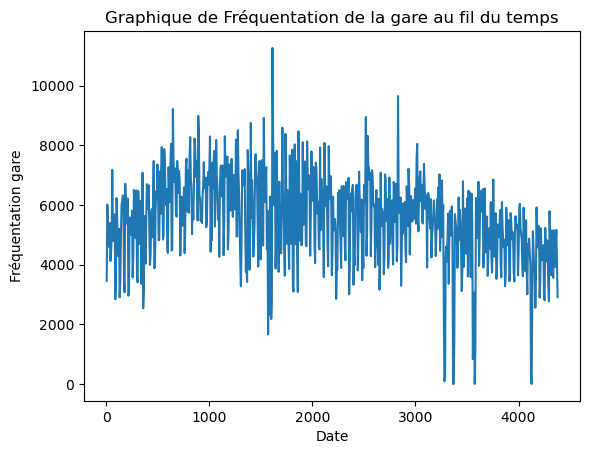

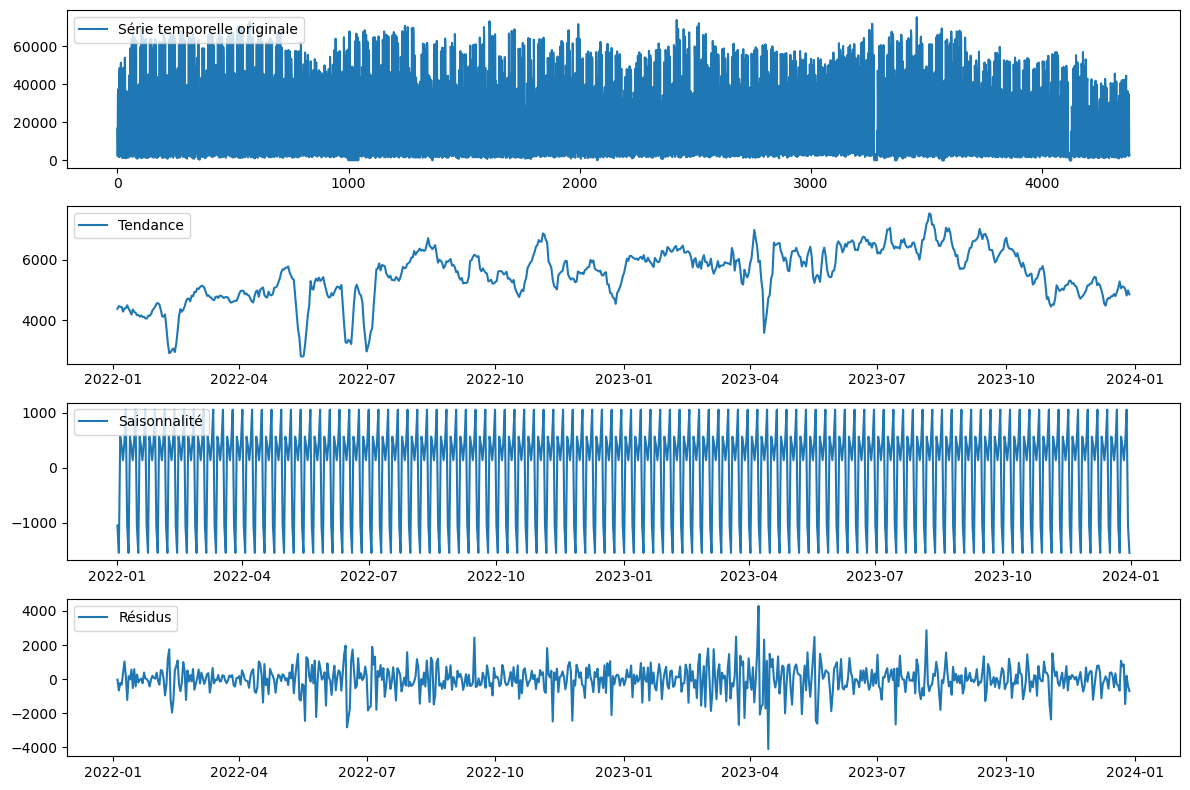

Déciles des résidus:
Décile 10% : -933.3882108183076
Décile 11% : -501.5557425584121
Décile 12% : -296.6414421743304
Décile 13% : -120.61759575376074
Décile 14% : 27.44638189480483
Décile 15% : 169.2062600021338
Décile 16% : 374.55255254454295
Décile 17% : 593.8329963725597
Décile 18% : 879.7494038728264


,UIC,DRG,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday,Affluence_inhabituelle
Date,,,,,,,,,,
2023-12-31,87476606,DRG B-CVL-PDL,3457,Vannes,2023,12,31,53,7,0
2023-12-30,87476606,DRG B-CVL-PDL,6017,Vannes,2023,12,30,52,6,0
2023-12-29,87476606,DRG B-CVL-PDL,5647,Vannes,2023,12,29,52,5,0
2023-12-28,87476606,DRG B-CVL-PDL,4601,Vannes,2023,12,28,52,4,0
2023-12-27,87476606,DRG B-CVL-PDL,4708,Vannes,2023,12,27,52,3,0
...,...,...,...,...,...,...,...,...,...,...
2022-01-05,87476606,DRG B-CVL-PDL,3922,Vannes,2022,1,5,01,3,0
2022-01-04,87476606,DRG B-CVL-PDL,4725,Vannes,2022,1,4,01,2,0
2022-01-03,87476606,DRG B-CVL-PDL,5165,Vannes,2022,1,3,01,1,0


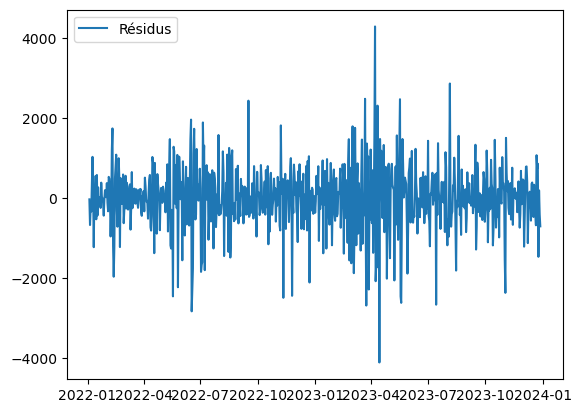

In [679]:
data_Vannes=data.query('Gare == "Vannes"')
#data=datalim.head(365)
#data.set_index('Date ', inplace=True)

# Tracer la série temporelle 'Fréquentation gare'
plt.plot(data_Vannes.index, data_Vannes['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()

data_Vannes.set_index('Date ', inplace=True)
# Appliquer la décomposition saisonnière
result = seasonal_decompose(data_Vannes['Fréquentation gare'], model='additive')

# Extraire les composants de tendance, saisonnalité et résidus
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Afficher les composants décomposés
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data['Fréquentation gare'], label='Série temporelle originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

# Calculer les déciles des résidus
deciles = np.percentile(residual.dropna(), np.arange(10, 100, 10))

# Afficher les déciles
print("Déciles des résidus:")
for i, decile_value in enumerate(deciles, 10):
    print(f"Décile {i}% : {decile_value}")

data_Vannes['Affluence_inhabituelle']=np.where(residual > seuil, 1, 0)

data_Vannes



## Saint-Brieuc


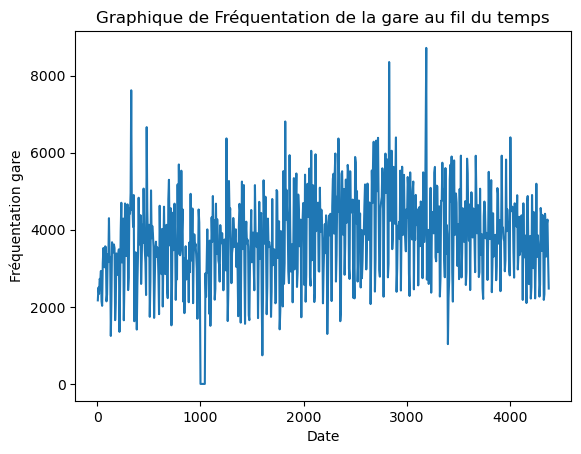

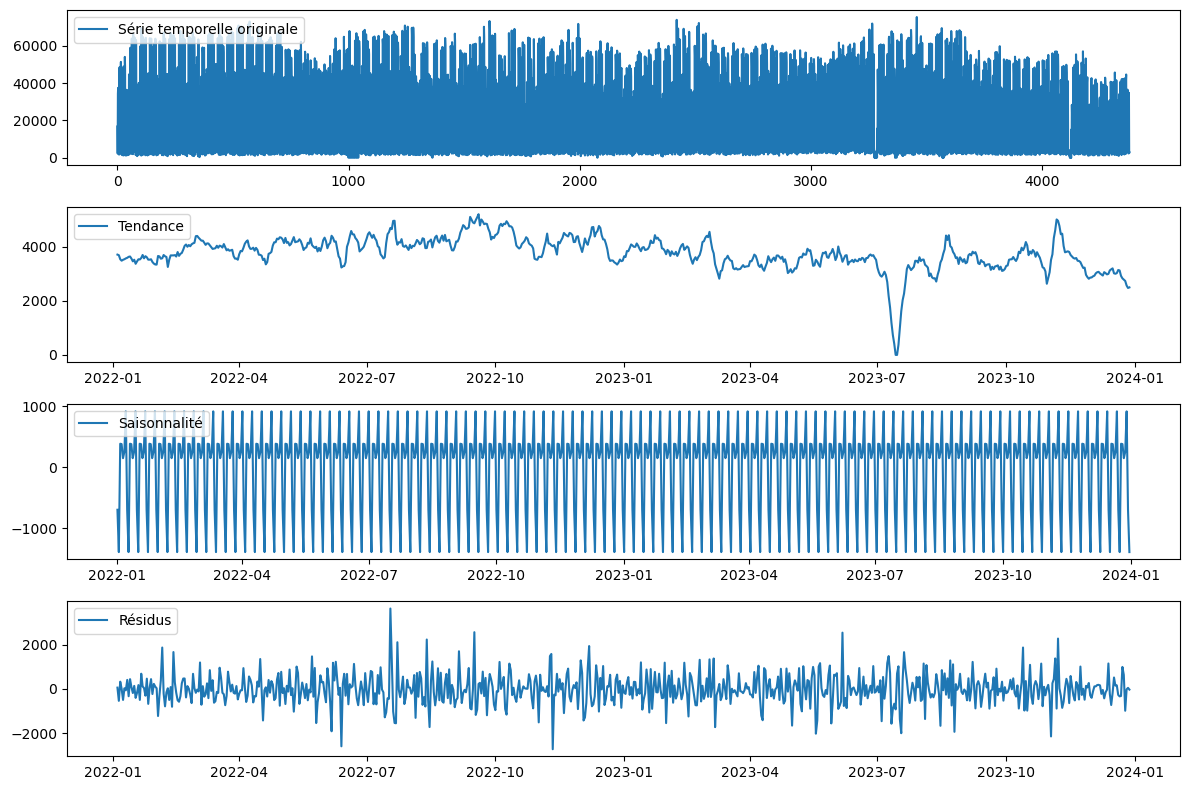

Déciles des résidus:
Décile 10% : -762.3086540366706
Décile 11% : -492.8570163539646
Décile 12% : -303.9525834082695
Décile 13% : -171.60080169483777
Décile 14% : -27.25258340826987
Décile 15% : 91.25193488896689
Décile 16% : 264.75187887701736
Décile 17% : 507.7400283489044
Décile 18% : 894.407850817699


,UIC,DRG,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday,Affluence_inhabituelle
Date,,,,,,,,,,
2023-12-31,87473009,DRG B-CVL-PDL,2167,Saint-Brieuc,2023,12,31,53,7,0
2023-12-30,87473009,DRG B-CVL-PDL,2499,Saint-Brieuc,2023,12,30,52,6,0
2023-12-29,87473009,DRG B-CVL-PDL,2337,Saint-Brieuc,2023,12,29,52,5,0
2023-12-28,87473009,DRG B-CVL-PDL,2725,Saint-Brieuc,2023,12,28,52,4,0
2023-12-27,87473009,DRG B-CVL-PDL,2678,Saint-Brieuc,2023,12,27,52,3,0
...,...,...,...,...,...,...,...,...,...,...
2022-01-05,87473009,DRG B-CVL-PDL,3304,Saint-Brieuc,2022,1,5,01,3,0
2022-01-04,87473009,DRG B-CVL-PDL,4152,Saint-Brieuc,2022,1,4,01,2,0
2022-01-03,87473009,DRG B-CVL-PDL,4262,Saint-Brieuc,2022,1,3,01,1,0


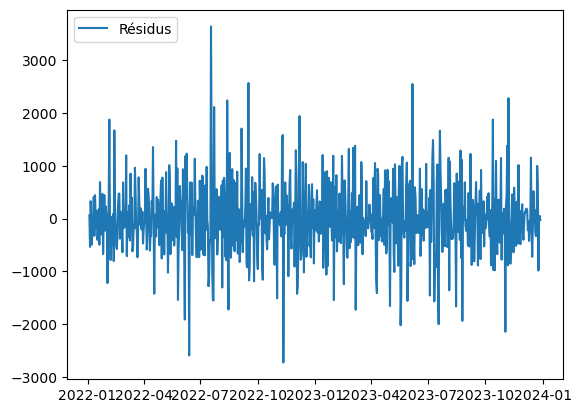

In [680]:
data_Saint_Brieuc=data.query('Gare == "Saint-Brieuc"')
#data=datalim.head(365)
#data.set_index('Date ', inplace=True)

# Tracer la série temporelle 'Fréquentation gare'
plt.plot(data_Saint_Brieuc.index, data_Saint_Brieuc['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()

data_Saint_Brieuc.set_index('Date ', inplace=True)
# Appliquer la décomposition saisonnière
result = seasonal_decompose(data_Saint_Brieuc['Fréquentation gare'], model='additive')

# Extraire les composants de tendance, saisonnalité et résidus
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Afficher les composants décomposés
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data['Fréquentation gare'], label='Série temporelle originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

# Calculer les déciles des résidus
deciles = np.percentile(residual.dropna(), np.arange(10, 100, 10))

# Afficher les déciles
print("Déciles des résidus:")
for i, decile_value in enumerate(deciles, 10):
    print(f"Décile {i}% : {decile_value}")

data_Saint_Brieuc['Affluence_inhabituelle']=np.where(residual > seuil, 1, 0)

data_Saint_Brieuc



## Guingamp


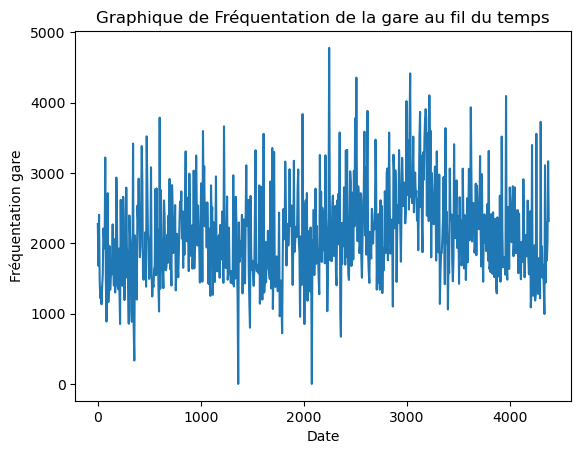

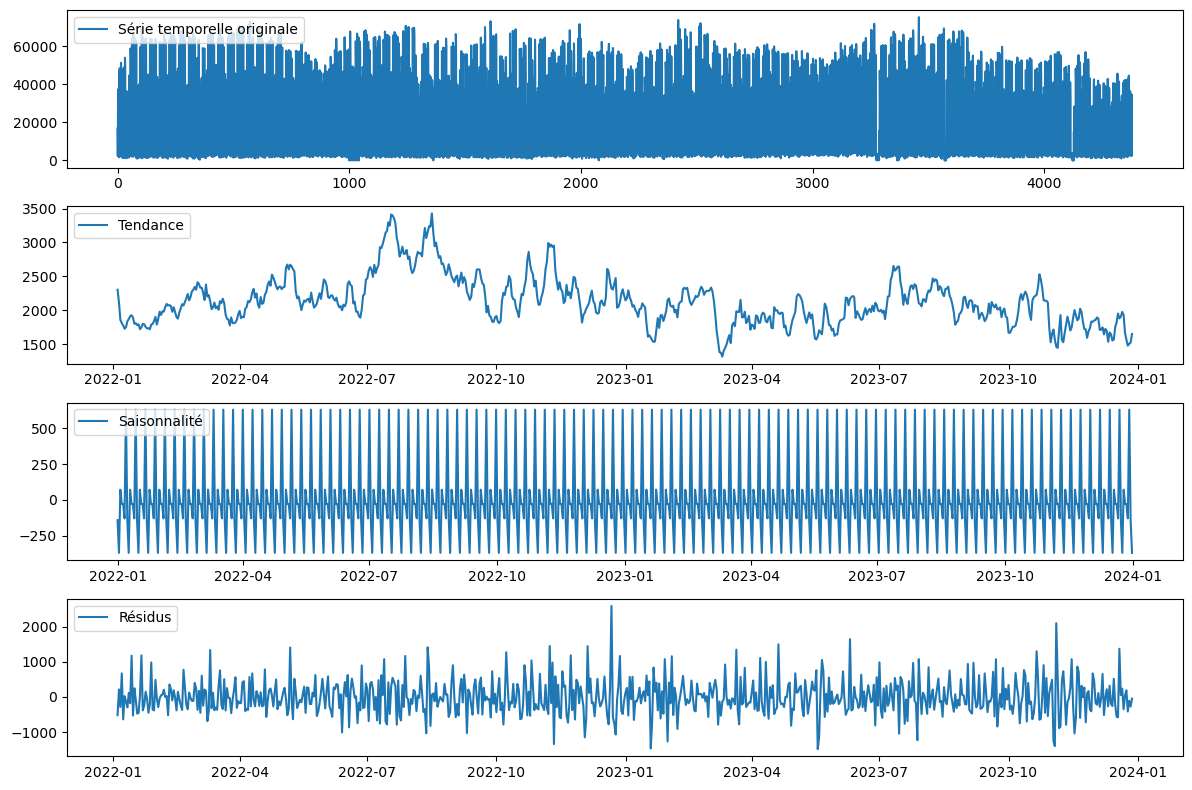

Déciles des résidus:
Décile 10% : -561.1566738046973
Décile 11% : -381.8178041791771
Décile 12% : -267.70282498361536
Décile 13% : -164.71699333953123
Décile 14% : -47.01682930453713
Décile 15% : 66.04377695813217
Décile 16% : 201.6177020621541
Décile 17% : 371.09072564051786
Décile 18% : 614.0924593437079


,UIC,DRG,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday,Affluence_inhabituelle
Date,,,,,,,,,,
2023-12-31,87473207,DRG B-CVL-PDL,2274,Guingamp,2023,12,31,53,7,0
2023-12-30,87473207,DRG B-CVL-PDL,1680,Guingamp,2023,12,30,52,6,0
2023-12-29,87473207,DRG B-CVL-PDL,2405,Guingamp,2023,12,29,52,5,0
2023-12-28,87473207,DRG B-CVL-PDL,1470,Guingamp,2023,12,28,52,4,0
2023-12-27,87473207,DRG B-CVL-PDL,1220,Guingamp,2023,12,27,52,3,0
...,...,...,...,...,...,...,...,...,...,...
2022-01-05,87473207,DRG B-CVL-PDL,2297,Guingamp,2022,1,5,01,3,0
2022-01-04,87473207,DRG B-CVL-PDL,1756,Guingamp,2022,1,4,01,2,0
2022-01-03,87473207,DRG B-CVL-PDL,2025,Guingamp,2022,1,3,01,1,0


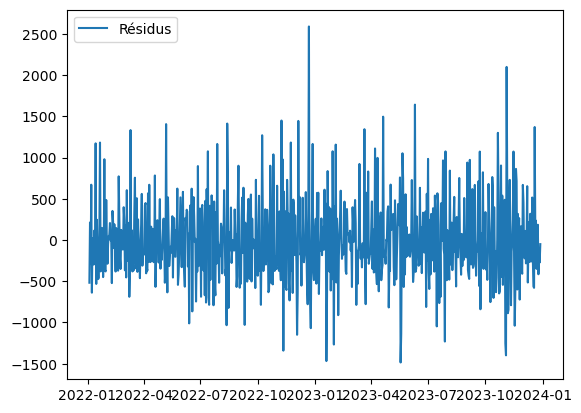

In [681]:
data_Guingamp=data.query('Gare == "Guingamp"')
#data=datalim.head(365)
#data.set_index('Date ', inplace=True)

# Tracer la série temporelle 'Fréquentation gare'
plt.plot(data_Guingamp.index, data_Guingamp['Fréquentation gare'])
plt.xlabel('Date')
plt.ylabel('Fréquentation gare')
plt.title('Graphique de Fréquentation de la gare au fil du temps')
plt.show()

data_Guingamp.set_index('Date ', inplace=True)
# Appliquer la décomposition saisonnière
result = seasonal_decompose(data_Guingamp['Fréquentation gare'], model='additive')

# Extraire les composants de tendance, saisonnalité et résidus
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Afficher les composants décomposés
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data['Fréquentation gare'], label='Série temporelle originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(residual, label='Résidus')
plt.legend(loc='upper left')

# Calculer les déciles des résidus
deciles = np.percentile(residual.dropna(), np.arange(10, 100, 10))

# Afficher les déciles
print("Déciles des résidus:")
for i, decile_value in enumerate(deciles, 10):
    print(f"Décile {i}% : {decile_value}")

data_Guingamp['Affluence_inhabituelle']=np.where(residual > seuil, 1, 0)

data_Guingamp



In [682]:
resultat = pd.concat([data_Nantes, data_Angers,data_rennes,data_Saint_Brieuc,data_Vannes,data_Guingamp], ignore_index=True)


In [683]:
resultat

,UIC,DRG,Fréquentation gare,Gare,annee,mois,jour,numero_semaine,weekday,Affluence_inhabituelle
0,87481002,DRG B-CVL-PDL,34282,Nantes,2023,12,31,53,7,0
1,87481002,DRG B-CVL-PDL,46633,Nantes,2023,12,30,52,6,0
2,87481002,DRG B-CVL-PDL,47517,Nantes,2023,12,29,52,5,0
3,87481002,DRG B-CVL-PDL,46520,Nantes,2023,12,28,52,4,0
4,87481002,DRG B-CVL-PDL,48908,Nantes,2023,12,27,52,3,0
...,...,...,...,...,...,...,...,...,...,...
4375,87473207,DRG B-CVL-PDL,2297,Guingamp,2022,1,5,01,3,0
4376,87473207,DRG B-CVL-PDL,1756,Guingamp,2022,1,4,01,2,0
4377,87473207,DRG B-CVL-PDL,2025,Guingamp,2022,1,3,01,1,0
4378,87473207,DRG B-CVL-PDL,3168,Guingamp,2022,1,2,01,7,0


In [684]:
resultat_lundi = resultat.query('weekday == 1')
mean(resultat_lundi['Fréquentation gare'])

24628.26121794872

In [685]:
# Enregistrer le DataFrame dans un fichier CSV
resultat.to_csv("../test.csv", sep=";", index=False)

In [693]:
# définir le chemin dans lequel se situe le fichier à importer:
chemin_data = 'P:/e_23_sae503_eq5/Données traitées/RésultatFest.csv'
# importer le fichier dans un objet python dataframe, nommé "data" pour l'exemple
Resulat_FEST = pd.read_csv(chemin_data, sep=';',encoding='utf-8')
Resulat_FEST

,Nom Event,Latitude,Longitude,Type d'évènement,Gare la plus proche,Distance à la gare (km),Date de début,Date de fin,AnnéeDébut,MoisDébut,JourDébut,JourSemaineDébut,AnnéeFin,MoisFin,JourFin,JourSemaineFin
0,Bars en Trans,48.117342,-1.707520,Fêtes et manifestations,Rennes,3.03,2023-12-02,2023-12-05,2023,12,2,6.0,2023,12,5,2.0
1,Rencontres Trans Musicales,48.117342,-1.707520,Fêtes et manifestations,Rennes,3.03,2023-12-02,2023-12-05,2023,12,2,6.0,2023,12,5,2.0
2,Marché de Noël,48.591025,-2.553243,Fêtes et manifestations,SaintBrieuc,18.15,2023-12-02,2023-12-05,2023,12,2,6.0,2023,12,5,2.0
3,Téléthon,48.421062,-2.661150,Fêtes et manifestations,SaintBrieuc,12.34,2023-12-02,2023-12-05,2023,12,2,6.0,2023,12,5,2.0
4,31e Salon d'Automne de Robien,48.505035,-2.762939,Fêtes et manifestations,SaintBrieuc,0.36,2023-12-02,2023-12-05,2023,12,2,6.0,2023,12,5,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,MOTS ZIK SOUS LES PINS,47.677652,-2.212299,Festival,Vannes,40.45,2023-11-09,2023-11-10,2023,11,9,4.0,2023,11,10,5.0
15412,FESTIVAL LEGEND'AIR,48.580125,-4.312938,Festival,Guingamp,86.24,2023-11-24,2023-11-24,2023,11,24,5.0,2023,11,24,5.0
15413,Les Nuits du Jazz de Nantes,47.231636,-1.548310,Festival,Nantes,1.69,2023-11-24,2023-11-24,2023,11,24,5.0,2023,11,24,5.0
15414,THERAP RIRE,47.231636,-1.548310,Festival,Nantes,1.69,2023-12-04,2023-12-16,2023,12,4,1.0,2023,12,16,6.0


In [737]:
# Appliquer la dummisation à la colonne 'Type d'évènement'
dummies = pd.get_dummies(Resulat_FEST['Type d\'évènement'], prefix='Type_Evenement')

# Concaténer les variables indicatrices avec le DataFrame d'origine
Resulat_FEST = pd.concat([Resulat_FEST, dummies], axis=1)

# Afficher le résultat
Resulat_FEST

,Nom Event,Latitude,Longitude,Type d'évènement,Gare la plus proche,Distance à la gare (km),Date de début,Date de fin,AnnéeDébut,MoisDébut,...,AnnéeFin,MoisFin,JourFin,JourSemaineFin,Type_Evenement_Festival,Type_Evenement_Fêtes et manifestations,Type_Evenement_Festival,Type_Evenement_Fêtes et manifestations,Type_Evenement_Festival,Type_Evenement_Fêtes et manifestations
0,Bars en Trans,48.117342,-1.707520,Fêtes et manifestations,Rennes,3.03,2023-12-02,2023-12-05,2023,12,...,2023,12,5,2.0,0,1,0,1,0,1
1,Rencontres Trans Musicales,48.117342,-1.707520,Fêtes et manifestations,Rennes,3.03,2023-12-02,2023-12-05,2023,12,...,2023,12,5,2.0,0,1,0,1,0,1
2,Marché de Noël,48.591025,-2.553243,Fêtes et manifestations,SaintBrieuc,18.15,2023-12-02,2023-12-05,2023,12,...,2023,12,5,2.0,0,1,0,1,0,1
3,Téléthon,48.421062,-2.661150,Fêtes et manifestations,SaintBrieuc,12.34,2023-12-02,2023-12-05,2023,12,...,2023,12,5,2.0,0,1,0,1,0,1
4,31e Salon d'Automne de Robien,48.505035,-2.762939,Fêtes et manifestations,SaintBrieuc,0.36,2023-12-02,2023-12-05,2023,12,...,2023,12,5,2.0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,MOTS ZIK SOUS LES PINS,47.677652,-2.212299,Festival,Vannes,40.45,2023-11-09,2023-11-10,2023,11,...,2023,11,10,5.0,1,0,1,0,1,0
15412,FESTIVAL LEGEND'AIR,48.580125,-4.312938,Festival,Guingamp,86.24,2023-11-24,2023-11-24,2023,11,...,2023,11,24,5.0,1,0,1,0,1,0
15413,Les Nuits du Jazz de Nantes,47.231636,-1.548310,Festival,Nantes,1.69,2023-11-24,2023-11-24,2023,11,...,2023,11,24,5.0,1,0,1,0,1,0
15414,THERAP RIRE,47.231636,-1.548310,Festival,Nantes,1.69,2023-12-04,2023-12-16,2023,12,...,2023,12,16,6.0,1,0,1,0,1,0


In [735]:
counts_by_event = Resulat_FEST.groupby(["Date de début", "Gare la plus proche"])[["Type_Evenement_Festival", "Type_Evenement_Fêtes et manifestations"]].agg(np.count_nonzero)
counts_by_event_reset = counts_by_event.reset_index()

counts_by_event_reset.head(25)

,Date de début,Gare la plus proche,Type_Evenement_Festival,Type_Evenement_Festival,Type_Evenement_Fêtes et manifestations,Type_Evenement_Fêtes et manifestations
0,2023-01-09,Guingamp,2,2,0,0
1,2023-01-19,Nantes,2,2,0,0
2,2023-01-19,Rennes,2,2,0,0
3,2023-01-25,Rennes,2,2,0,0
4,2023-01-26,SaintBrieuc,2,2,0,0
5,2023-01-29,Guingamp,2,2,0,0
6,2023-01-30,Nantes,2,2,0,0
7,2023-01-31,Nantes,2,2,0,0
8,2023-02-01,Rennes,2,2,0,0
9,2023-02-05,Guingamp,2,2,0,0


In [736]:

# Enregistrer le DataFrame dans un fichier CSV
counts_by_event_reset.to_csv("../test.csv", sep=";", index=False)


In [200]:
# définir le chemin dans lequel se situe le fichier à importer:
chemin_data = 'P:/e_23_sae503_eq5/Données traitées/FichierCSVFinal.csv'
# importer le fichier dans un objet python dataframe, nommé "data" pour l'exemple
Resultat = pd.read_csv(chemin_data, sep=';',encoding='utf-8')
dummies=pd.get_dummies(Resultat['Jour Semaine'])
data= pd.concat([dummies,Resultat],axis=1)


In [246]:
## TODO 
# Step 1: définition de l'arbre
# utiliser DecisionTreeClassifier
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier
data_1=data.query('Affluence_inhabituelle == 1')
data_0=data.query('Affluence_inhabituelle == 0')
data_0

# Sélectionnez toutes les lignes de data_1
data_tree = data_1.copy()

# Sélectionnez 20% des lignes de data_0 de manière aléatoire
sampled_data_0 = data_0.sample(frac=0.2, random_state=42)

# Concaténez les deux DataFrames
data_tree = pd.concat([data_tree, sampled_data_0])

# Réorganisez les index si nécessaire
data_tree.reset_index(drop=True, inplace=True)

# Affichez le nouveau jeu de données
data_tree

for col in ["Nombre de festival","Nombre de manifestation","Jour férié", "Veille Jour férié","Pendant les vacances","Veille de vacances","Jour de mouvement social","Veille de mouvement social"]:
    data_tree[col] = label_encoder.fit_transform(data_tree[col])

In [247]:
train,test=train_test_split(data_tree, random_state=2023, test_size=0.4, stratify = data_tree["Affluence_inhabituelle"])

In [248]:
tree1 = DecisionTreeClassifier( max_depth = 4)

In [249]:
label_encoder.set_params


<bound method BaseEstimator.set_params of LabelEncoder()>

In [250]:
tree1.fit(train[["Nombre de festival","Nombre de manifestation","Jour férié", "Veille Jour férié","Pendant les vacances","Veille de vacances","Jour de mouvement social","Veille de mouvement social"]],train[["Affluence_inhabituelle"]])


DecisionTreeClassifier(max_depth=4)

|--- feature_2 <= 0.50
|   |--- feature_4 <= 0.50
|   |   |--- feature_1 <= 5.00
|   |   |   |--- class: 0
|   |   |--- feature_1 >  5.00
|   |   |   |--- feature_1 <= 6.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  6.50
|   |   |   |   |--- class: 0
|   |--- feature_4 >  0.50
|   |   |--- class: 0
|--- feature_2 >  0.50
|   |--- feature_4 <= 0.50
|   |   |--- feature_0 <= 0.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  0.50
|   |   |   |--- feature_1 <= 5.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  5.50
|   |   |   |   |--- class: 0
|   |--- feature_4 >  0.50
|   |   |--- feature_1 <= 5.50
|   |   |   |--- class: 0
|   |   |--- feature_1 >  5.50
|   |   |   |--- feature_0 <= 2.00
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  2.00
|   |   |   |   |--- class: 1



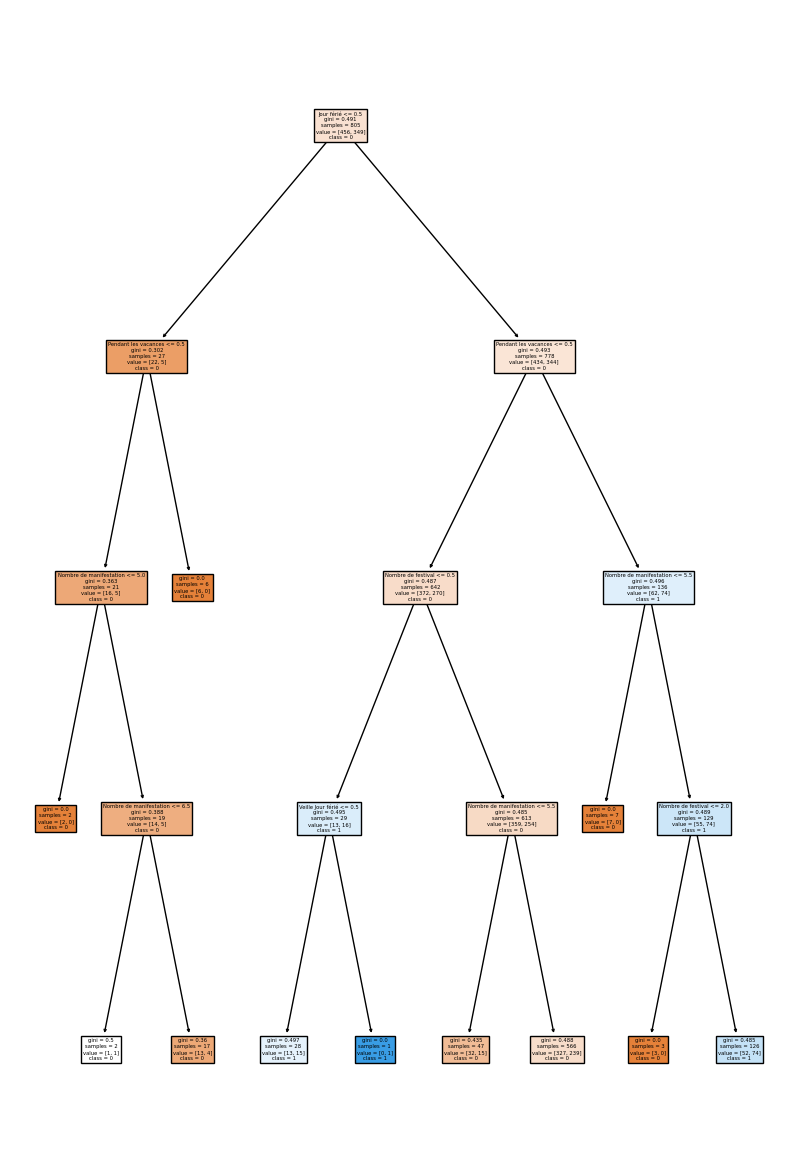

In [251]:
# Step 3: représentation de l'arbre (texte)
from sklearn import tree
text_representation = tree.export_text(tree1)
print(text_representation)


# Convertir les classes en chaînes de caractères
class_names = [str(cls) for cls in tree1.classes_]

# Représentation de l'arbre (graphique)
fig = plt.figure(figsize=(10,15))
tree_plot = tree.plot_tree(tree1, feature_names=["Nombre de festival","Nombre de manifestation","Jour férié", "Veille Jour férié","Pendant les vacances","Veille de vacances"], class_names=class_names, filled=True)
plt.show()

In [253]:
for col in ["Nombre de festival", "Nombre de manifestation", "Friday", "Saturday", "Sunday", "Jour férié", "Veille Jour férié", "Pendant les vacances", "Veille de vacances", "Jour de mouvement social", "Veille de mouvement social"]:
    print(f"Valeurs uniques dans {col} (Entraînement) : {train[col].unique()}")
    print(f"Valeurs uniques dans {col} (Test) : {test[col].unique()}")

    
    
    

Valeurs uniques dans Nombre de festival (Entraînement) : [4 0 5 1 2]
Valeurs uniques dans Nombre de festival (Test) : [4 0 5 3 2 1]
Valeurs uniques dans Nombre de manifestation (Entraînement) : [7 6 5 4 2 1 0 3]
Valeurs uniques dans Nombre de manifestation (Test) : [7 6 4 2 5 1]
Valeurs uniques dans Friday (Entraînement) : [0 1]
Valeurs uniques dans Friday (Test) : [0 1]
Valeurs uniques dans Saturday (Entraînement) : [0 1]
Valeurs uniques dans Saturday (Test) : [0 1]
Valeurs uniques dans Sunday (Entraînement) : [0 1]
Valeurs uniques dans Sunday (Test) : [0 1]
Valeurs uniques dans Jour férié (Entraînement) : [1 0]
Valeurs uniques dans Jour férié (Test) : [1 0]
Valeurs uniques dans Veille Jour férié (Entraînement) : [0 1]
Valeurs uniques dans Veille Jour férié (Test) : [0 1]
Valeurs uniques dans Pendant les vacances (Entraînement) : [0 1]
Valeurs uniques dans Pendant les vacances (Test) : [0 1]
Valeurs uniques dans Veille de vacances (Entraînement) : [0 1]
Valeurs uniques dans Veille de 